In [ ]:
!pip install qiskit
!pip install qutip.qip
!pip install qutip
!pip install pylatexenc
!pip install qiskit-aer
!pip install qiskit_dynamics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.5/107.5 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.3/129.3 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=e25918c4b9f3a16530dbf101e59a1ee0717be1a3de66c29393fce020707afe18
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc

In [ ]:
import qutip as qt
import pylatexenc
import qiskit as qs
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from tqdm import tqdm
from scipy.linalg import expm, sinm, cosm
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
from qutip_qip.operations import *

In [ ]:
#dados usado no artigo
array_2d_size_7 = [
    [0.05, 2.41, 1.34, 2.57, 0.10, -0.32, -0.54],
    [0.20, 2.47, 1.45, 2.50, 0.17, -0.25, -0.47],
    [0.40, 2.55, 1.56, 2.41, 0.27, -0.15, -0.37],
    [0.60, 2.64, 1.69, 2.31, 0.37, -0.05, -0.27],
    [0.70, 2.67, 1.74, 2.26, 0.42, -0.001, -0.22],
    [0.80, 2.71, 1.79, 2.21, 0.467, 0.05, -0.17],
    [1.00, 2.78, 1.86, 2.12, 0.56, 0.14, -0.08],
    [1.20, 2.84, 1.92, 2.03, 0.65, 0.22, 0.002],
    [1.40, 2.89, 1.96, 1.96, 0.72, 0.30, 0.08],
    [1.50, 2.91, 1.97, 1.92, 0.75, 0.33, 0.11]
]
array=array_2d_size_7

# Contas

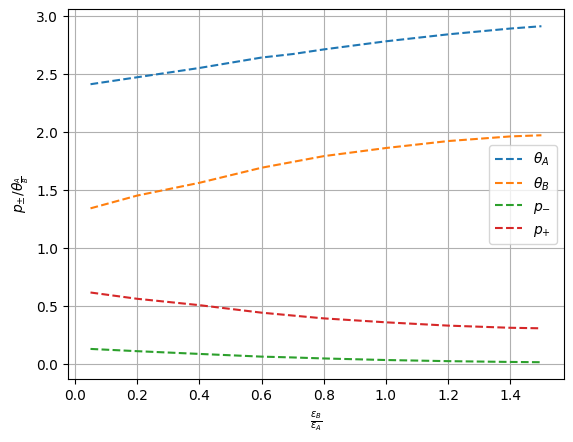

In [ ]:
#vetores com thetas
theta1=[array[i][1] for i in range(len(array))]
theta2=[array[i][2] for i in range(len(array))]
e=[array[i][0] for i in range(len(array))]
vec1=[]
vec2=[]
#calculo
for i,eb in enumerate(theta1):
  vec1.append(np.cos(theta1[i]*0.5)**2)
  vec2.append(np.cos(theta2[i]*0.5)**2)
#plot
plt.plot(e,theta1,'--',label='$\\theta_{A}$')
plt.plot(e,theta2,'--',label='$\\theta_{B}$')
plt.plot(e,vec1,'--',label='$p_{-}$')
plt.plot(e,vec2,'--',label='$p_{+}$')
plt.ylabel('$p_{\pm}/\\theta_{\\frac{A}{B}}$')
plt.xlabel('$\\frac{\\epsilon_{B}}{\\epsilon_{A}}$')
plt.grid()
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import curve_fit
def func_2(x,a):
  ba,bb,ea,eb=1,2,a,a*x

  Za=np.exp(ea*ba*0.5)+np.exp(-ea*ba*0.5)
  Zb=np.exp(eb*bb*0.5)+np.exp(-eb*bb*0.5)

  pa=np.exp(-ba*ea)/Za
  pb=np.exp(-bb*eb)/Zb

  a=1/(Za*Zb)

  pm=(pa+pb-np.sqrt((pb-pa)**2+4*a**2))*0.5
  return pm

popt,pcov= curve_fit(func_2,e,vec1,maxfev=5000, method='trf')
print('Valor do coeficiente do campo',popt[0],'±',np.sqrt(pcov[0][0]))

Valor do coeficiente do campo 0.4178390892091527 ± 0.014143394995105326


In [ ]:
def x_p(alpha, epsilon_a, beta_a, epsilon_b, beta_b):
    return 0.5 * (1 + np.sqrt(1 - 16 * alpha**2 / (np.tanh(epsilon_b * beta_b / 2) - np.tanh(epsilon_a * beta_a / 2))**2))


def rhoab(beta_a, epsilon_a, beta_b, epsilon_b):

    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    x=x_p(1/(Z_a*Z_b), epsilon_a, beta_a, epsilon_b, beta_b)

    # Calcular os elementos individuais
    element_00 = np.exp(-0.5 * beta_a * epsilon_a - 0.5 * beta_b * epsilon_b) / (Z_a * Z_b)

    element_11 = (1 / 4) * (np.tanh(epsilon_a * beta_a / 2)*(-np.tanh(epsilon_b * beta_b / 2) + (2 * x - 1)) +
                                      (2 * x - 1) * -np.tanh(epsilon_b * beta_b / 2) + 1)

    element_22 = (1/4) * (np.tanh(epsilon_a * beta_a / 2) * ((-np.tanh(epsilon_b * beta_b / 2)) - 2 * x + 1) -
                         2 * x * (-np.tanh(epsilon_b * beta_b / 2)) + (-np.tanh(epsilon_b * beta_b / 2)) + 1)

    element_33 = np.exp(0.5 * beta_a * epsilon_a + 0.5 * beta_b * epsilon_b) / (Z_a * Z_b)

    # Criar a matriz
    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, 1/(Z_a*Z_b), 0],
        [0, 1/(Z_a*Z_b), element_22, 0],
        [0, 0, 0, element_33]
    ])

    return matrix

def rhoarhob(beta_a, epsilon_a, beta_b, epsilon_b):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa-pa*pb
    element_22 = alpha**2 + pb-pa*pb
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return matrix



In [ ]:
def q2(e, b,ea=1,ba=1,l = 0.6):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    # Constantes



    bb=b*ba
    eb=e*ea

    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 1/(Za*Zb)

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    rho_ab=np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab


    #Partial_swap

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron(idtt,[[1, 0], [0, 0]]) + np.kron((idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot

    # rho_f
    rho_ab_f=evol@rho_ab@evol.conj().T

    #traço parcial

    rho_a=np.trace(rho_ab.reshape(2, 2, 2, 2),axis1=1,axis2=3)

    rho_b=np.trace(rho_ab.reshape(2, 2, 2, 2),axis1=0,axis2=2)

    rho_a_f=np.trace(rho_ab_f.reshape(2, 2, 2, 2),axis1=1,axis2=3)

    rho_b_f=np.trace(rho_ab_f.reshape(2, 2, 2, 2),axis1=0,axis2=2)

    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)

    return -np.trace((rho_a_f-rho_a)@H_A),-np.trace((rho_b_f-rho_b)@H_B)

In [ ]:
def w1(e, b,ea=1,ba=1,l = 0.6):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sx=np.array([[1, 0], [0, -1]])
    # Constantes



    bb=b*ba
    eb=e*ea

    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sx
    H_B = -0.5 * eb * sx

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 0

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    rho_ab=np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab

    #Partial_swap

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron( idtt,[[1, 0], [0, 0]]) + np.kron( (idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot

    # rho_f

    rho_ab_f=evol@rho_ab@evol.conj().T

    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)

    return np.trace((rho_ab_f-rho_ab)@Hab)

In [ ]:
def q1(e, b,ea=1,ba=1,l = 0.6):
    # Definindo a matriz identidade 2x2
    idtt= np.eye(2)

    # Definindo as matrizes Pauli
    sy = np.array([[0, -1j], [1j, 0]])
    sz=np.array([[1, 0], [0, -1]])
    # Constantes


    bb=b*ba
    eb=e*ea

    # Hamiltoniana do sistema
    H_A = -0.5 * ea * sz
    H_B = -0.5 * eb * sz

    # Função partição
    Za = np.trace(expm(-ba * H_A))

    Zb = np.trace(expm(-bb * H_B))

    #correlação
    a = 0

    qmp=qt.tensor(qt.sigmam(),qt.sigmap())
    qpm=qt.tensor(qt.sigmap(),qt.sigmam())
    #operador densidade

    chiab=a*qpm.full()+np.conjugate(a)*qmp.full()

    rho_ab=np.kron(expm(-ba * H_A)/Za,expm(-bb * H_B)/Zb)+chiab


    #Partial_swap

    # Calculando a matriz evol
    cnot=np.array([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])

    lamb=np.kron( idtt,[[1, 0], [0, 0]]) + np.kron( (idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

    evol = cnot@lamb@cnot
    rho_ab_f=evol@rho_ab@evol.conj().T
    # rho_f
    #densidade reduzidda

    #traço parcial
    rho_a=np.trace(rho_ab.reshape(2, 2, 2, 2),axis1=1,axis2=3)

    rho_b=np.trace(rho_ab.reshape(2, 2, 2, 2),axis1=0,axis2=2)

    rho_a_f=np.trace(rho_ab_f.reshape(2, 2, 2, 2),axis1=1,axis2=3)

    rho_b_f=np.trace(rho_ab_f.reshape(2, 2, 2, 2),axis1=0,axis2=2)
    #hamiltoniana

    Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)

    return -np.trace((rho_a_f-rho_a)@H_A),-np.trace((rho_b_f-rho_b)@H_B)

<ipython-input-10-0311662d8aa7>:35: ComplexWarning: Casting complex values to real discards the imaginary part
  vec1[i]=np.trace((rho_f-rho_0)@Hab)/epsilon_a
<ipython-input-6-ffb3d005153d>:2: RuntimeWarning: invalid value encountered in sqrt
  return 0.5 * (1 + np.sqrt(1 - 16 * alpha**2 / (np.tanh(epsilon_b * beta_b / 2) - np.tanh(epsilon_a * beta_a / 2))**2))
<ipython-input-10-0311662d8aa7>:42: ComplexWarning: Casting complex values to real discards the imaginary part
  vec2[i]=np.trace((rho_f-rho_0)@Hab)/epsilon_a
<ipython-input-10-0311662d8aa7>:49: ComplexWarning: Casting complex values to real discards the imaginary part
  qa_mean1[j],qb_mean1[j]=q1(e[j],2,l=0.6)
<ipython-input-10-0311662d8aa7>:50: ComplexWarning: Casting complex values to real discards the imaginary part
  w_mean1[j]=w1(e[j],2,l=0.6)
<ipython-input-10-0311662d8aa7>:57: ComplexWarning: Casting complex values to real discards the imaginary part
  qa_mean[j],qb_mean[j]=q2(e[j],2,1,1,l=0.8)


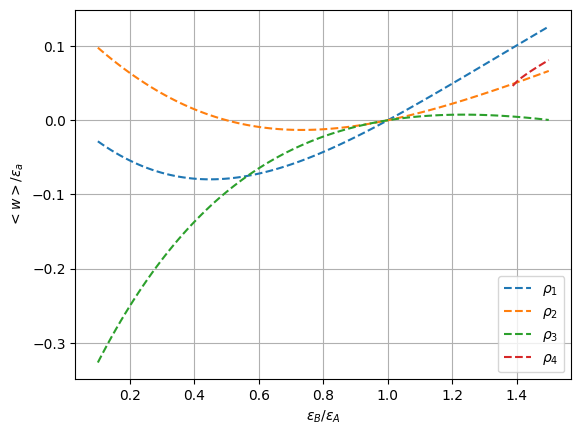

In [ ]:
#trabalho
e=np.linspace(0.1,1.5,101)

beta_a, beta_b=1,2
l=0.6

idtt= np.eye(2)
sy = np.array([[0, -1j], [1j, 0]])
sz=np.array([[1, 0], [0, -1]])

vec1=np.zeros(len(e))
vec2=np.zeros(len(e))

# Calculando a matriz evol

cnot=np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0],
                  [0, 0, 0, 1],
                  [0, 0, 1, 0]])

lamb=np.kron(idtt,[[1, 0], [0, 0]]) + np.kron((idtt* np.sqrt(1 - l) + 1j * sy * np.sqrt(l)),[[0, 0], [0, 1]])

evol = cnot@lamb@cnot



for i,eb in enumerate(e):
  #Apendice
  epsilon_a=1
  H_B = -0.5 *  eb* sz
  H_A = -0.5 * epsilon_a * sz
  Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)
  rho_0=rhoarhob(beta_a, epsilon_a, beta_b, eb)
  rho_f=evol@rho_0@evol.conj().T
  vec1[i]=np.trace((rho_f-rho_0)@Hab)/epsilon_a
  #alterado
  epsilon_a=1
  H_A = -0.5 * epsilon_a * sz
  Hab=np.kron(H_A,idtt)+np.kron(idtt,H_B)
  rho_0=rhoab(beta_a, epsilon_a, beta_b, eb)
  rho_f=evol@rho_0@evol.conj().T
  vec2[i]=np.trace((rho_f-rho_0)@Hab)/epsilon_a
#sem correlação
w_mean1=np.zeros((101))
qa_mean1=np.zeros((101))
qb_mean1=np.zeros((101))

for j in range(len(e)):
  qa_mean1[j],qb_mean1[j]=q1(e[j],2,l=0.6)
  w_mean1[j]=w1(e[j],2,l=0.6)
#correlação
w_mean=np.zeros((101))
qa_mean=np.zeros((101))
qb_mean=np.zeros((101))

for j in range(len(e)):
  qa_mean[j],qb_mean[j]=q2(e[j],2,1,1,l=0.8)
  w_mean[j]=-(qa_mean[j]+qb_mean[j])
#plot
plt.plot(e,w_mean,'--',label='$\\rho_{1}$')
plt.plot(e,w_mean1,'--',label='$\\rho_{2}$')
plt.plot(e,vec1,'--',label='$\\rho_{3}$')
plt.plot(e,vec2,'--',label='$\\rho_{4}$')
plt.ylabel('$<w>/\\epsilon_a$')
plt.xlabel('$\\epsilon_{B}/\\epsilon_{A}$')
plt.grid()
plt.legend()
plt.show()

In [ ]:
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
from qutip_qip.operations import *
# definindo U+-(x)
def u_minus(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return u_minus
def u_plus(x):
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return u_minus


#criando função fazer gate dado qubit de controle e alvo
def control_target(control,target,num_bits,U):
  # Define projectors for the control qubit
  P0 = qt.basis(2, 0) * qt.basis(2, 0).dag()  # Projector onto the |0> state
  P1 = qt.basis(2, 1) * qt.basis(2, 1).dag()  # Projector onto the |1> state
  #criando qobj
  C0 =qt.Qobj(1)
  C1 =qt.Qobj(1)
  #criando gate com controle e alvo
  for i in range(num_bits):
    #criando operação no alvo
    if target==i:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,U)
    #escolhendo o controle
    elif control==i:

      C0=tensor(C0,P0)
      C1=tensor(C1,P1)

    else:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,qeye(2))
  return np.array((C0+C1).full())


# gate de rotação eixo x
def rx_gate(theta):
    cos = np.cos(theta / 2,dtype=complex)
    sin = np.sin(theta / 2,dtype=complex)
    return np.array([[cos, -1j*sin], [-1j*sin, cos]])

# cnot em numpy
def cnot_gate(control, target, num_qubits):
    return np.array(cnot(N=num_qubits,control=control, target=target).full())

# box 1
def box_1(theta_A, theta_B):
    num_qubits = 4

    I = np.identity(4)
    #rotação no eixo x
    first_rotation = np.kron(rx_gate(theta_A),I rx_gate(theta_B))
    rotation = tensor(tensor(rx(theta_A),tensor(qeye(2),qeye(2))),rx(theta_B))
    cnot1=cnot(control=0,target=1)
    #cnot1 = cnot_gate(control=0, target=1, num_qubits=2)
    cnot2 = cnot(control=1, target=0)
    #cnot2 = cnot_gate(control=1, target=0, num_qubits=2)

    cnot3 = tensor(cnot1,cnot2)

    circuit_matrix = cnot3*rotation

    return circuit_matrix
#box 2
def box_2(x):
    num_qubits = 4

    circuit =cnot_gate(0, 3, num_qubits)@control_target(3,0,4,u_minus(x))@cnot_gate(0, 3, num_qubits)

    return circuit

# box 3
def box_3(x):
    num_qubits = 4

    circuit =cnot_gate(1, 2, num_qubits)@control_target(2,1,4,u_minus(x))@cnot_gate(1, 2, num_qubits)

    return circuit

#Nesse ponto reduzimos o estado
def box_4(x):
    num_qubits = 4

    circuit = cnot_gate(1, 2, num_qubits)@control_target(2,1,4,u_plus(x))@cnot_gate(1, 2, num_qubits)

    return circuit



In [ ]:
def thetas(e,b,ea=1,ba=1,l=0.6):
  #parametro de correlação
  #parametros do sistema
  ea=1
  ba=1
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb

  #coeficiente

  a=1/(Za*Zb)

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pm,dtype=complex))
  theta_b=2*np.arccos(np.sqrt(pp,dtype=complex))
  #x(\alpha)
  x=abs(p_a-p_b)/(pp-pm)*0.5+0.5
  phi_a=np.arcsin(np.sqrt(x))
  phi_b=phi_a-np.arcsin(np.sqrt(l))
  #print(theta_a,theta_b,phi_a,phi_b)
  return theta_a,theta_b,phi_a,phi_b


In [ ]:
theta_a,theta_b,phi_a,phi_b=thetas(1,2,1)
print(theta_a,theta_b,phi_a,phi_b)
print(np.cos(theta_a/2)**2,np.cos(theta_b/2)**2)
print(np.cos(theta_a/2)**2*np.cos(theta_b/2)**2)
print(np.cos(theta_a/2)**2*np.sin(theta_b/2)**2)
print(np.sin(theta_a/2)**2*np.cos(theta_b/2)**2)

(3.141592653589793-0.45252506778361656j) (2.0736229892523403+0j) 0.9821088625079043 0.09603173871529058
(-0.05207435309634106+2.8664608221827255e-17j) (0.2590478751634372-0j)
(-0.013489750520117708+7.425505852256741e-18j)
(-0.038584602576223356+2.1239102369570517e-17j)
(0.2725376256835549-7.425505852256741e-18j)


In [ ]:
phi=np.array([[1,0]])
phi=tensor(qt.basis(2,0),qt.basis(2,0),qt.basis(2,0),qt.basis(2,0))
theta_a,theta_b,phi_a,phi_b=thetas(1,2,1)
print(theta_a,theta_b)
phi_t=box_1(theta_a, theta_b)*phi
rho=phi_t*phi_t.dag()
print(ptrace(Qobj(rho,dims=[[2, 2, 2, 2], [2, 2, 2, 2]]),[1,2]))
print(rho.tr())
print(rhoarhob(1,1,2,1))

(3.141592653589793-0.45252506778361656j) (2.0736229892523403+0j)
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.01348975 0.         0.         0.        ]
 [0.         0.0385846  0.         0.        ]
 [0.         0.         0.27253763 0.        ]
 [0.         0.         0.         0.77953673]]
1.1041487061926822
[[-0.01348975  0.          0.          0.        ]
 [ 0.          0.17661097  0.14367669  0.        ]
 [ 0.          0.14367669  0.05734205  0.        ]
 [ 0.          0.          0.          0.77953673]]


In [ ]:

idtt = np.eye(2)
ea=1
n=101
#ea=np.linspace(0.0,1.5,n)
#e=np.linspace(0,1.5,n)
e=[1]
w=np.zeros((n),dtype=complex)
for i,eb in enumerate(e):
  #theta_a,theta_b,phi_a,phi_b=thetas(ea[i],2,l=0.6)
  theta_a,theta_b,phi_a,phi_b=thetas(eb,2,1)
  print(theta_a,theta_b,phi_a,phi_b)
  bb=2
  ba=1
  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea)/Za
  p_b=np.exp(-bb*eb)/Zb

  a=1/(Za*Zb)

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))
  #determinando x
  x=((p_a-p_b)/(pp-pm)+1)*0.5

  #estado fundamental
  phi=np.array([[1,0]])
  phi=np.kron(np.kron(np.kron(phi,phi),phi),phi).T

  #print(box_1(theta_a,theta_b)@phi)
  #gates
  phi_0=box_3(x)@box_2(x)@box_1(theta_a,theta_b)@phi

  phi_f=box_4(0.6)@phi_0


  #traço parcial
  phi_0=(phi_0@np.conj(phi_0).T)

  phi_f=(phi_f@np.conj(phi_f).T)

  #hamiltoniano

  sz=np.array([[1, 0], [0, -1]])
  Ha=-0.5*ea*sz
  Hb=-0.5*eb*sz

  #traço parcial
  phi_0_red=ptrace(Qobj(phi_0, dims=[[2, 2, 2, 2], [2, 2, 2, 2]]), [1,2])
  print(phi_0_red)
  print(rhoab(1, 1, 2, 1))
  print(rhoarhob(1,1,2,1))
  phi_f_red=ptrace(Qobj(phi_f, dims=[[2, 2, 2, 2], [2, 2, 2, 2]]), [1,2])
  #trabalho
  Hab=Qobj(np.kron(Ha,idtt)+np.kron(idtt,Hb), dims=[[2, 2], [2, 2]])

  #print((phi_f_red-phi_0_red)*Hab)
  #w[i]=((phi_f_red-phi_0_red)*Hab).tr()/ea

#plt.plot(e,w)
#plt.grid()
#plt.ylabel('$<w>/\\epsilon_a$')
#plt.xlabel('$\\epsilon_{B}/\\epsilon_{A}$')
#plt.show()

(3.141592653589793-0.45252506778361656j) (2.0736229892523403+0j) 0.9821088625079043 0.09603173871529058
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.01348975  0.          0.          0.        ]
 [ 0.          0.20040414 -0.10803984  0.        ]
 [ 0.         -0.10803984  0.11071809  0.        ]
 [ 0.          0.          0.          0.77953673]]
[[0.0320586  0.         0.         0.        ]
 [0.                nan 0.14367669 0.        ]
 [0.         0.14367669        nan 0.        ]
 [0.         0.         0.         0.64391426]]
[[-0.01348975  0.          0.          0.        ]
 [ 0.          0.17661097  0.14367669  0.        ]
 [ 0.          0.14367669  0.05734205  0.        ]
 [ 0.          0.          0.          0.77953673]]


<ipython-input-6-ffb3d005153d>:2: RuntimeWarning: invalid value encountered in sqrt
  return 0.5 * (1 + np.sqrt(1 - 16 * alpha**2 / (np.tanh(epsilon_b * beta_b / 2) - np.tanh(epsilon_a * beta_a / 2))**2))


In [ ]:
from scipy.optimize import curve_fit
def func_2(x,a):
  ba,bb,ea,eb=1,2,a,a*x

  Za=np.exp(ea*ba*0.5)+np.exp(-ea*ba*0.5)
  Zb=np.exp(eb*bb*0.5)+np.exp(-eb*bb*0.5)

  pa=np.exp(-ba*ea)/Za
  pb=np.exp(-bb*eb)/Zb

  a=1/(Za*Zb)

  pm=(pa+pb-np.sqrt((pb-pa)**2+4*a**2))*0.5
  return pm

popt,pcov= curve_fit(func_2,e,vec1,maxfev=5000, method='trf')
print('Valor do coeficiente do campo',popt[0],'±',np.sqrt(pcov[0][0]))

Valor do coeficiente do campo 1.06646728515625 ± 996.0047404836001
